# Danish 1.3 "blitz" versus Danish 1.2 FAM output, one visit (v1)

**Author:** Aaron Roodman  
**Date Created:** 2026-09-22  
**Last Modified:** 2026-09-22  
**Status:** Complete  
**Keywords:** AOS, FAM, blitz, Danish, donut, Zernike, format review  

## Description

Column-by-column review of Josh Meyers' new Danish 1.3 "blitz" unpaired Full Array Mode
(FAM) donut output against the Danish 1.2 output currently used in this repository, plus a
value cross-check of the wavefront Zernikes on a single visit. This is the format review
that precedes writing a blitz reader; Josh has asked for feedback on missing and extra
columns and on the table metadata.

Key functionality:
1. Load four products for one FAM triplet on `day_obs = 20260315`: the blitz FAM table
   (`donutBlitzFamResults`), the blitz corner/in-focus table (`donutBlitzResults`), the
   Danish 1.2 Butler table (`aggregateAOSVisitTableRaw`), and the Danish 1.2 processed
   `donuts.parquet` row group for the same visit.
2. Build a column census across all four, separating shared, blitz-only and Danish-1.2-only
   columns, with dtype, array shape and table metadata keys.
3. Establish the blitz Noll indexing and the row-selection accounting on each side.
4. Match the same physical donuts per CCD on detector pixel position, separately for each
   side of focus, then compare the deviation and intrinsic Zernikes in micrometres of
   wavefront.

**Main results:** the intrinsic wavefronts agree to a median 3.9e-05 µm of wavefront
against a median |intrinsic| of 0.0069 µm of wavefront, so units and frame match exactly;
the fitted deviations correlate only moderately (median Pearson r = 0.74 over 21 Noll),
with per-Noll mean offsets larger than the scatter on several terms. Only 3 of 58 blitz
column names are shared with the Danish 1.2 table, both blitz products have empty
metadata, and the blitz `snr` is not the same quantity as the Danish 1.2 `snr`. Section 10
collects the format feedback.

**Output:** Tables and plots inline; no files written.

**Based on:** Item #1 of `~/Documents/todo-ideas.md`; `aos/docs/ts_wep_zernike_intrinsics.md`
for the meaning of `zk`, `zk_intrinsic` and `zk_deviation`; the matching idiom of
`aos/code/processing_compare/compare_donuts.py`.

## Change Log

| Date | Author | Description |
|------|--------|-------------|
| 2026-09-22 | Aaron Roodman | Initial version: four-product census, Noll basis, donut match, Zernike comparison |
| 2026-09-22 | Aaron Roodman | Corrected the donut match: each side of focus against its own Danish 1.2 centroid, with the constant few-pixel centroid offset removed |

## Table of Contents

1. [Parameters](#params)
2. [Setup & Imports](#setup)
3. [Helper Functions](#functions)
4. [Data Access](#data)
5. [Column Census](#census)
6. [Noll Basis and Selection Accounting](#noll)
7. [Matching Donuts](#match)
8. [Zernike Comparison](#zernike)
9. [Corner / In-Focus Product](#corner)
10. [Findings for Josh](#findings)

<a id='params'></a>
## 1. Parameters

In [1]:
# ============================================================
# Parameters — All configurable values collected here
# ============================================================

BUTLER_REPO = '/repo/main'

# The first FAM triplet on this night that is processed in BOTH the blitz and the
# Danish 1.2 collections. The FAM key is the EXTRA-focal exposure; the in-focus
# (acq) member is the extra seq_num + 1.
DAY_OBS = 20260315
SEQ_INTRA = 121                       # intra-focal member, img_type cwfs
SEQ_EXTRA = 122                       # extra-focal member = the FAM key
SEQ_ACQ = 123                         # in-focus member, img_type acq
VISIT_EXTRA = DAY_OBS * 100000 + SEQ_EXTRA     # 2026031500122
VISIT_ACQ = DAY_OBS * 100000 + SEQ_ACQ         # 2026031500123

# Danish 1.2: the param_set currently in use. Note it reads the danish_1_2_0_alpha0
# collection (dir_name danish_1_2); danish_1_2_0 has no 20260315 coverage.
PARAM_SET_OLD = 'fam_danish_1_2_0_wep17_6_1_refitWCS_bin2x'
COLL_OLD = ('LSSTCam/runs/aos/fam/danish_1_2_0_alpha0/wep_17_6_1/dv_4_5_0/'
            'bin_x2/paired/refitWcs')

# Danish 1.3 blitz collections (Josh Meyers, ts_wep tag blitz-prototype-v2).
COLL_BLITZ_FAM = 'u/jmeyers3/t614_fam_unpaired'
COLL_BLITZ_CORNER = 'u/jmeyers3/t614_corner_unpaired'

SOURCES = {
    'blitz_fam': dict(collection=COLL_BLITZ_FAM, dataset='donutBlitzFamResults',
                      visit=VISIT_EXTRA, role='Danish 1.3 unpaired, FAM science CCDs'),
    'blitz_corner': dict(collection=COLL_BLITZ_CORNER, dataset='donutBlitzResults',
                         visit=VISIT_ACQ, role='Danish 1.3 unpaired, corner WFS at in-focus'),
    'old_butler': dict(collection=COLL_OLD, dataset='aggregateAOSVisitTableRaw',
                       visit=VISIT_EXTRA, role='Danish 1.2 paired, as read from the Butler'),
    'old_parquet': dict(collection=PARAM_SET_OLD, dataset='donuts.parquet',
                        visit=VISIT_EXTRA, role='Danish 1.2 after run_mktable processing'),
}

# Zernike conventions. The blitz zk_deviation_* vector has length 27 and is
# 0-INDEXED (column j is Noll j); the Danish 1.2 table carries only the 21 fitted
# Noll listed in its meta['nollIndices']. NOLL is the map from old column order to
# blitz column index, asserted in section 6.
NOLL = list(range(4, 20)) + list(range(22, 27))       # 21 fitted Noll indices
COORD_BLITZ = 'ocs'                   # blitz column suffix, lower case
COORD_OLD = 'OCS'                     # Danish 1.2 column suffix, upper case

TOL_PIX = 5.0                         # per-CCD donut match tolerance [pixels]

print(f'FAM triplet on day_obs = {DAY_OBS}: '
      f'intra seq_num = {SEQ_INTRA}, extra seq_num = {SEQ_EXTRA} (FAM key), '
      f'in-focus seq_num = {SEQ_ACQ}')
print(f'FAM visit id = {VISIT_EXTRA}, in-focus visit id = {VISIT_ACQ}')

FAM triplet on day_obs = 20260315: intra seq_num = 121, extra seq_num = 122 (FAM key), in-focus seq_num = 123
FAM visit id = 2026031500122, in-focus visit id = 2026031500123


<a id='setup'></a>
## 2. Setup & Imports

In [2]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr

from lsst.daf.butler import Butler

# Notebook path bootstrap: walk up to the topic directory (the one holding code/),
# which works at any depth under aos/notebooks/.
_TOPIC = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'code').is_dir())
sys.path.insert(0, str(_TOPIC.parent))                 # repo root -> common/
sys.path.insert(0, str(_TOPIC / 'code'))               # flat cross-study modules
for _d in sorted((_TOPIC / 'code').glob('*/')):        # code/<study>/ subdirs
    if _d.is_dir() and not _d.name.startswith(('_', '.')):
        sys.path.insert(0, str(_d))

from common.utils import setup_plotting, nmad
import compare_donuts as cd
from lsst.ts.intrinsic.wavefront import intrinsics_lib
from lsst.ts.intrinsic.wavefront.common.zernike_names import NOLL_NAMES

setup_plotting()

# resolve_side resolves output/ relative to the working directory, so run from the
# topic directory.
os.chdir(_TOPIC)
print(f'topic directory = {_TOPIC}')

        Use pytest instead. [astropy.tests.runner]
        Use pytest instead.


        Use pytest instead. [astropy.utils.decorators]
        Use pytest instead.


INFO:lsst.ts.utils.tai:Update leap second table


INFO:lsst.ts.utils.tai:current_tai uses the system TAI clock


topic directory = /sdf/home/r/roodman/notebooks/rubin-work/aos


<a id='functions'></a>
## 3. Helper Functions

In [3]:
def column_census(tables):
    """Per-column dtype and array shape across several tables, as one frame.

    Parameters
    ----------
    tables : `dict`
        Maps a short source label to an object exposing ``colnames`` (an
        `astropy.table.Table`) or ``columns`` (a `pandas.DataFrame`).

    Returns
    -------
    census : `pandas.DataFrame`
        One row per column name seen in any table, one column per source. Each
        cell is ``'dtype'`` for a scalar column, ``'dtype(n,)'`` for an array
        column, or the empty string when the source lacks that column.
    """
    def _cols(t):
        return list(t.colnames) if hasattr(t, 'colnames') else list(t.columns)

    def _describe(t, c):
        a = np.asarray(t[c])
        if a.ndim == 1 and a.dtype == object and len(a) and isinstance(a[0], np.ndarray):
            # pandas stores a fixed-length array column as object-of-ndarray
            return f'{a[0].dtype}{np.shape(a[0])}'
        if a.ndim > 1:
            return f'{a.dtype}{a.shape[1:]}'
        return str(a.dtype)

    all_cols, seen = [], set()
    for t in tables.values():
        for c in _cols(t):
            if c not in seen:
                seen.add(c)
                all_cols.append(c)
    rows = {}
    for label, t in tables.items():
        cols = set(_cols(t))
        rows[label] = [_describe(t, c) if c in cols else '' for c in all_cols]
    return pd.DataFrame(rows, index=pd.Index(all_cols, name='column'))


def focus_side(table):
    """Label each row of a blitz table by its side of focus.

    The blitz ``defocal_offsets`` column is a 3-vector of defocal offsets in
    metres. Which element carries the offset is **not** the same in the two blitz
    products -- the FAM table varies element 1 and the corner table element 0 --
    so the varying element is found rather than assumed.

    Parameters
    ----------
    table : `astropy.table.Table`
        Blitz table carrying ``defocal_offsets``.

    Returns
    -------
    side : `numpy.ndarray`
        String array of ``'intra'`` (negative offset) or ``'extra'`` (positive).
    element : `int`
        Index of the ``defocal_offsets`` element that varies.
    """
    off = np.asarray(table['defocal_offsets'], dtype=float)
    varying = [k for k in range(off.shape[1]) if len(np.unique(off[:, k])) > 1]
    if len(varying) != 1:
        raise ValueError(f'expected exactly one varying defocal_offsets element, '
                         f'found {varying}')
    k = varying[0]
    return np.where(off[:, k] < 0, 'intra', 'extra'), k


def match_one_side(blitz, old, *, ox_col, oy_col, tol_pix, shift=None):
    """Match blitz rows to Danish 1.2 rows per CCD on detector pixel position.

    Adapted from ``compare_donuts.match_donuts_per_ccd``, which cannot be used
    directly: the blitz table names its detector ``det_name`` and its position
    ``x_det`` / ``y_det``, while the Danish 1.2 table uses ``detector`` and a
    separate centroid per side of focus.

    The two products' centroid conventions differ by a constant offset of a few
    pixels, so the match is done in two passes: a first pass measures the median
    offset from the nearest neighbours, and the second pass matches with that
    offset removed. Pass an explicit ``shift`` to skip the first pass.

    Parameters
    ----------
    blitz : `astropy.table.Table`
        Blitz rows for **one** side of focus, already quality selected.
    old : `astropy.table.Table`
        Danish 1.2 rows, already restricted to ``used``.
    ox_col, oy_col : `str`
        Danish 1.2 centroid columns to match against, in detector pixels. Use the
        columns for the same side of focus as ``blitz``.
    tol_pix : `float`
        Maximum separation for a match, in detector pixels, applied after the
        offset is removed.
    shift : `tuple` of `float`, optional
        ``(dx, dy)`` offset in detector pixels to subtract from the blitz
        positions. Measured from the data when omitted.

    Returns
    -------
    idx_old : `numpy.ndarray`
        Integer indices into ``old``.
    idx_blitz : `numpy.ndarray`
        Integer indices into ``blitz``, parallel to ``idx_old``.
    sep_pix : `numpy.ndarray`
        Separation of each matched pair after the offset is removed, in pixels.
    shift : `tuple` of `float`
        The offset actually used, in detector pixels.
    """
    det_o = np.asarray(old['detector'], dtype=str)
    det_b = np.asarray(blitz['det_name'], dtype=str)
    xo = np.asarray(old[ox_col], dtype=float)
    yo = np.asarray(old[oy_col], dtype=float)
    xb = np.asarray(blitz['x_det'], dtype=float)
    yb = np.asarray(blitz['y_det'], dtype=float)
    dets = np.unique(det_b)

    if shift is None:
        # First pass: unconstrained nearest neighbour, to measure the offset.
        dxs, dys = [], []
        for det in dets:
            oi = np.where(det_o == det)[0]
            bi = np.where(det_b == det)[0]
            if len(oi) == 0 or len(bi) == 0:
                continue
            tree = cKDTree(np.column_stack([xo[oi], yo[oi]]))
            _, k = tree.query(np.column_stack([xb[bi], yb[bi]]))
            dxs.append(xb[bi] - xo[oi][k])
            dys.append(yb[bi] - yo[oi][k])
        shift = (float(np.median(np.concatenate(dxs))),
                 float(np.median(np.concatenate(dys))))

    io_all, ib_all, sep_all = [], [], []
    for det in dets:
        oi = np.where(det_o == det)[0]
        bi = np.where(det_b == det)[0]
        if len(oi) == 0 or len(bi) == 0:
            continue
        tree = cKDTree(np.column_stack([xo[oi], yo[oi]]))
        dist, k = tree.query(np.column_stack([xb[bi] - shift[0],
                                              yb[bi] - shift[1]]),
                             distance_upper_bound=tol_pix)
        good = np.isfinite(dist) & (dist < tol_pix)
        io_all.append(oi[k[good]])
        ib_all.append(bi[good])
        sep_all.append(dist[good])
    if not io_all:
        z = np.empty(0, dtype=int)
        return z, z, np.empty(0, dtype=float), shift
    return (np.concatenate(io_all), np.concatenate(ib_all),
            np.concatenate(sep_all), shift)


def deduplicate(idx_old, idx_blitz, sep_pix):
    """Keep only the nearest blitz match for each Danish 1.2 row.

    Parameters
    ----------
    idx_old, idx_blitz : `numpy.ndarray`
        Parallel match index arrays.
    sep_pix : `numpy.ndarray`
        Match separation in detector pixels, used to pick the winner.

    Returns
    -------
    keep : `numpy.ndarray`
        Boolean mask over the input pairs.
    """
    keep = np.zeros(len(idx_old), dtype=bool)
    best = {}
    for i in np.argsort(sep_pix, kind='stable'):
        key = int(idx_old[i])
        if key not in best:
            best[key] = i
            keep[i] = True
    return keep


def zk_label(j):
    """``'Z4 Defocus'``-style label for Noll index `j`."""
    return f'Z{j} {NOLL_NAMES.get(j, "")}'.strip()


def corr_pair(x, y):
    """Pearson r, Spearman rho and n over the finite entries of `x` and `y`.

    Returns
    -------
    r : `float`
        Pearson correlation coefficient (dimensionless), NaN if n < 3.
    rho : `float`
        Spearman rank correlation coefficient (dimensionless), NaN if n < 3.
    n : `int`
        Number of finite pairs used.
    """
    g = np.isfinite(x) & np.isfinite(y)
    n = int(g.sum())
    if n < 3:
        return np.nan, np.nan, n
    return float(pearsonr(x[g], y[g])[0]), float(spearmanr(x[g], y[g])[0]), n

<a id='data'></a>
## 4. Data Access

Four products for the one triplet. `get_aggregate_zernikes` issues its own
`butler.get` without a `collections` argument, so the Danish 1.2 Butler is constructed
with that collection baked in. The processed Danish 1.2 table is read one row group at a
time out of the combined 12 GB `donuts.parquet` via `VisitSource`, so `run_mktable` is not
re-run here.

In [4]:
# --- Danish 1.3 blitz, both products ---
butler_blitz = Butler(BUTLER_REPO)
blitz_fam = butler_blitz.get('donutBlitzFamResults', collections=COLL_BLITZ_FAM,
                             instrument='LSSTCam', visit=VISIT_EXTRA)
blitz_corner = butler_blitz.get('donutBlitzResults', collections=COLL_BLITZ_CORNER,
                                instrument='LSSTCam', visit=VISIT_ACQ)
print(f'blitz FAM    : {len(blitz_fam):6d} rows, {len(blitz_fam.colnames)} columns  '
      f'(visit {VISIT_EXTRA})')
print(f'blitz corner : {len(blitz_corner):6d} rows, {len(blitz_corner.colnames)} columns  '
      f'(visit {VISIT_ACQ})')

blitz FAM    :   7652 rows, 58 columns  (visit 2026031500122)
blitz corner :     68 rows, 61 columns  (visit 2026031500123)


In [5]:
# --- Danish 1.2 from the Butler ---
# Two tables, deliberately: the RAW dataset carries the table metadata that the
# format review is about, while get_aggregate_zernikes returns an enriched table
# (extra derived columns, empty meta) plus the per-visit metadata as a dict. Both
# are needed -- the raw one for the census, the enriched one for the comparison.
butler_old = Butler(BUTLER_REPO, collections=COLL_OLD, instrument='LSSTCam')
camera = butler_old.get('camera', instrument='LSSTCam',
                        collections='LSSTCam/calib/unbounded')

old_raw = butler_old.get('aggregateAOSVisitTableRaw',
                         day_obs=DAY_OBS, seq_num=SEQ_EXTRA)
old_butler, old_meta = intrinsics_lib.get_aggregate_zernikes(
    butler_old, DAY_OBS, SEQ_EXTRA, COORD_OLD, camera)

print(f'Danish 1.2 raw Butler dataset        : {len(old_raw)} rows, '
      f'{len(old_raw.colnames)} columns, {len(old_raw.meta)} metadata keys')
print(f'Danish 1.2 via get_aggregate_zernikes: {len(old_butler)} rows, '
      f'{len(old_butler.colnames)} columns, {len(old_butler.meta)} metadata keys')
print(f'  columns the library adds: '
      f'{sorted(set(old_butler.colnames) - set(old_raw.colnames))}')
print(f'  used == True            : '
      f'{int(np.asarray(old_butler["used"], bool).sum())} rows')
print('  returned visit_meta keys:', sorted(old_meta))

Danish 1.2 raw Butler dataset        : 3414 rows, 48 columns, 12 metadata keys
Danish 1.2 via get_aggregate_zernikes: 2691 rows, 61 columns, 0 metadata keys
  columns the library adds: ['blur', 'chi2', 'day_obs', 'intra_extra_offset_x_arcsec', 'intra_extra_offset_y_arcsec', 'lstsq_cost', 'lstsq_optimality', 'lstsq_status', 'matched_intra_extra', 'model_dx', 'model_dy', 'model_flux', 'seq_num']
  used == True            : 2691 rows
  returned visit_meta keys: ['alt', 'az', 'band', 'day_obs', 'dec', 'mjd', 'nollIndices', 'ra', 'seq_num', 'skyAngle', 'visit']


In [6]:
# --- Danish 1.2 after processing: one row group of the combined donut parquet ---
donuts_path, visits_path, fits_path = cd.resolve_side(param_set=PARAM_SET_OLD)
src = cd.VisitSource(donuts_path)
old_parquet = src.read(DAY_OBS, SEQ_EXTRA)
print(f'processed parquet: {donuts_path}')
print(f'  visit ({DAY_OBS}, {SEQ_EXTRA}): {len(old_parquet)} rows, '
      f'{len(old_parquet.columns)} columns')
print(f'  total visits in the combined table: {len(src.keys())}')

processed parquet: output/fam_processing/danish_1_2/donuts.parquet
  visit (20260315, 122): 2691 rows, 48 columns
  total visits in the combined table: 3385


<a id='census'></a>
## 5. Column Census

The format review proper: every column of every product side by side, with dtype and
array shape. A blank cell means that source does not carry the column.

In [7]:
census = column_census({'blitz_fam': blitz_fam, 'blitz_corner': blitz_corner,
                        'old_raw': old_raw, 'old_enriched': old_butler,
                        'old_parquet': old_parquet})
print(f'{len(census)} distinct column names across the five tables '
      '(old_raw is the Danish 1.2 Butler dataset, old_enriched adds the '
      'get_aggregate_zernikes columns)')
with pd.option_context('display.max_rows', 250, 'display.width', 250):
    display(census)

119 distinct column names across the five tables (old_raw is the Danish 1.2 Butler dataset, old_enriched adds the get_aggregate_zernikes columns)


,blitz_fam,blitz_corner,old_raw,old_enriched,old_parquet
column,,,,,
visit_id,int64,int64,,,
det_id,int64,int64,,,
det_name,<U7,<U7,,,
donut_id,int64,int64,,,
band,<U1,<U1,,,
candidate,bool,bool,,,
x_det,float64,float64,,,
y_det,float64,float64,,,
thx_ccs,float64,float64,,,


In [8]:
# The format comparison that matters is blitz FAM against the Danish 1.2 dataset as
# delivered by the Butler, before any of this repository's own processing.
blitz_cols = set(blitz_fam.colnames)
old_cols = set(old_raw.colnames)

print(f'blitz FAM columns: {len(blitz_cols)}   Danish 1.2 raw columns: {len(old_cols)}'
      f'   shared by name: {len(blitz_cols & old_cols)}')
print('\nshared column names:')
print('   ', sorted(blitz_cols & old_cols))
print('\nblitz-only columns (new in Danish 1.3):')
for c in sorted(blitz_cols - old_cols):
    print(f'    {c}')
print('\nDanish 1.2-only columns (absent from the blitz FAM product):')
for c in sorted(old_cols - blitz_cols):
    print(f'    {c}')

blitz FAM columns: 58   Danish 1.2 raw columns: 48   shared by name: 3

shared column names:
    ['coord_dec', 'coord_ra', 'snr']

blitz-only columns (new in Danish 1.3):
    astrom_mag
    band
    bkg
    bkg_std
    blend_frac
    candidate
    defocal_offsets
    det_id
    det_name
    donut_id
    donut_radius
    fit_dx
    fit_dy
    fit_flux
    flux
    group_fit_cost
    group_fit_elapsed
    group_fit_nfev
    group_fit_njev
    group_fit_optimality
    group_fit_outcome
    group_fit_success
    group_fwhm
    group_id
    group_setup_elapsed
    group_size
    inner_frac
    n_nearby_astrom
    n_nearby_photo
    nearby_astrom_dx_det
    nearby_astrom_dy_det
    nearby_astrom_mag
    nearby_photo_dx_det
    nearby_photo_dy_det
    nearby_photo_mag
    outer_frac
    outer_sector_minmax_frac
    photo_mag
    rejected_inner_frac
    rejected_outer_frac
    rejected_sat
    rejected_snr
    thx_ccs
    thx_ocs
    thy_ccs
    thy_ocs
    visit_id
    x_det
    y_det
    zk_

In [9]:
# Table metadata. The blitz products carry none, which is the single biggest format
# gap: the Danish 1.2 raw table's meta is what supplies the pupil Noll set and the
# per-visit pointing and rotator angles.
print(f'blitz FAM     meta keys: {list(blitz_fam.meta.keys())}')
print(f'blitz corner  meta keys: {list(blitz_corner.meta.keys())}')
print(f'Danish 1.2 raw meta keys: {list(old_raw.meta.keys())}')
print('\nDanish 1.2 raw meta values (estimatorInfo summarized, it is per donut):')
for k, v in old_raw.meta.items():
    if k == 'estimatorInfo':
        keys = sorted(v) if hasattr(v, 'keys') else type(v).__name__
        print(f'  {k:18s} -> per-donut diagnostics, keys = {keys}')
    elif k == 'nollIndices':
        print(f'  {k:18s} = {[int(j) for j in v]}')
    else:
        print(f'  {k:18s} = {v}')
print('\nprocessed-parquet columns not in the raw Butler table '
      '(added downstream by run_mktable and the telemetry attach):')
print('   ', sorted(set(old_parquet.columns) - old_cols))

blitz FAM     meta keys: []
blitz corner  meta keys: []
Danish 1.2 raw meta keys: ['visit', 'parallacticAngle', 'rotAngle', 'rotTelPos', 'ra', 'dec', 'az', 'alt', 'band', 'mjd', 'nollIndices', 'estimatorInfo']

Danish 1.2 raw meta values (estimatorInfo summarized, it is per donut):
  visit              = 2026031500122
  parallacticAngle   = 1.77020838017223
  rotAngle           = 0.196329641767376
  rotTelPos          = 0.0030824116099572585
  ra                 = 1.93433890072167
  dec                = -0.492088492384987
  az                 = 4.71058107081745
  alt                = 1.21878397306936
  band               = i
  mjd                = 61115.087210054946
  nollIndices        = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
  estimatorInfo      -> per-donut diagnostics, keys = ['blur_clipped', 'chi_square', 'exception_status', 'fit_success', 'fwhm', 'lstsq_cost', 'lstsq_nfev', 'lstsq_njev', 'lstsq_optimality', 'lstsq_status', 'lstsq_success', 

<a id='noll'></a>
## 6. Noll Basis and Selection Accounting

The blitz deviation vector has 27 entries and the intrinsic 67, against 21 in the
Danish 1.2 table. Asserting the indexing convention is what makes the value comparison in
section 8 meaningful.

In [10]:
dev_b = np.asarray(blitz_fam[f'zk_deviation_{COORD_BLITZ}'], dtype=float)
int_b = np.asarray(blitz_fam[f'zk_intrinsic_{COORD_BLITZ}'], dtype=float)
# nollIndices lives on the raw table's meta, and get_aggregate_zernikes also hands it
# back in its visit_meta dict; both should agree.
noll_old = [int(j) for j in old_raw.meta['nollIndices']]
assert noll_old == [int(j) for j in old_meta['nollIndices']], \
    'nollIndices disagree between the raw table meta and the returned visit_meta'

print(f'blitz zk_deviation_{COORD_BLITZ} shape = {dev_b.shape}   '
      f'zk_intrinsic_{COORD_BLITZ} shape = {int_b.shape}')
print(f'Danish 1.2 nollIndices ({len(noll_old)} entries) = {noll_old}')

n_finite = np.isfinite(dev_b).sum(axis=0)
print(f'\nblitz deviation, per column index (of {len(dev_b)} rows):')
print('  index : n_finite : max |value| [um of wavefront]')
for j in range(dev_b.shape[1]):
    col = dev_b[:, j]
    mx = np.nanmax(np.abs(col)) if n_finite[j] else np.nan
    note = ''
    if n_finite[j] == 0:
        note = '  <- all NaN'
    elif np.allclose(col[np.isfinite(col)], 0.0):
        note = '  <- identically zero'
    print(f'   Z{j:2d}   : {n_finite[j]:6d}   : {mx:.4g}{note}')

blitz zk_deviation_ocs shape = (7652, 27)   zk_intrinsic_ocs shape = (7652, 67)
Danish 1.2 nollIndices (21 entries) = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]

blitz deviation, per column index (of 7652 rows):
  index : n_finite : max |value| [um of wavefront]
   Z 0   :   6933   : 0  <- identically zero
   Z 1   :   6933   : 0  <- identically zero
   Z 2   :   6933   : 0  <- identically zero
   Z 3   :   6933   : 0  <- identically zero
   Z 4   :   6931   : 1.276
   Z 5   :   6931   : 3.406
   Z 6   :   6931   : 17.56
   Z 7   :   6931   : 2.363
   Z 8   :   6931   : 3.625
   Z 9   :   6931   : 2.837
   Z10   :   6931   : 7.556
   Z11   :   6931   : 0.6021
   Z12   :   6931   : 2.687
   Z13   :   6931   : 8.71
   Z14   :   6931   : 2.303
   Z15   :   6931   : 1.06
   Z16   :   6931   : 4.791
   Z17   :   6931   : 0.9477
   Z18   :   6931   : 1.699
   Z19   :   6931   : 5.282
   Z20   :      0   : nan  <- all NaN
   Z21   :      0   : nan  <- all N

In [11]:
# The blitz vector is 0-indexed: column j is Noll j. Indices 0-3 are not fitted
# (identically zero) and 20, 21 are all-NaN -- exactly the two the Danish 1.2
# nollIndices omits between 19 and 22.
zero_idx = [j for j in range(dev_b.shape[1])
            if np.isfinite(dev_b[:, j]).any()
            and np.allclose(dev_b[:, j][np.isfinite(dev_b[:, j])], 0.0)]
nan_idx = [j for j in range(dev_b.shape[1]) if np.isfinite(dev_b[:, j]).sum() == 0]
assert zero_idx == [0, 1, 2, 3], f'unexpected zero columns: {zero_idx}'
assert nan_idx == [20, 21], f'unexpected all-NaN columns: {nan_idx}'
assert noll_old == NOLL, f'Danish 1.2 nollIndices {noll_old} != NOLL {NOLL}'
print('Noll convention asserted: blitz zk_deviation is 0-indexed, '
      'identically zero at Noll 0-3, all-NaN at Noll 20, 21.')
print(f'Mapping used for the comparison: blitz[:, NOLL] with NOLL = {NOLL}')
print(f'blitz intrinsic finite through Noll index '
      f'{max(j for j in range(int_b.shape[1]) if np.isfinite(int_b[:, j]).any())} '
      f'(vector length {int_b.shape[1]})')

Noll convention asserted: blitz zk_deviation is 0-indexed, identically zero at Noll 0-3, all-NaN at Noll 20, 21.
Mapping used for the comparison: blitz[:, NOLL] with NOLL = [4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 22, 23, 24, 25, 26]
blitz intrinsic finite through Noll index 66 (vector length 67)


In [12]:
# Row accounting on each side. group_fit_success is the blitz analogue of the
# Danish 1.2 `used` flag; verify it is exactly the finite-deviation set.
fit_ok = np.asarray(blitz_fam['group_fit_success'], dtype=bool)
dev_finite = np.isfinite(dev_b[:, NOLL]).all(axis=1)
print(f'blitz group_fit_success True        : {int(fit_ok.sum())} rows')
print(f'blitz finite on the 21 fitted Noll : {int(dev_finite.sum())} rows')
print(f'  disagreement (either direction)  : '
      f'{int((fit_ok != dev_finite).sum())} rows')

print(f'\nblitz FAM row accounting (of {len(blitz_fam)} rows):')
for col in ('candidate', 'rejected_sat', 'rejected_inner_frac',
            'rejected_outer_frac', 'rejected_snr', 'group_fit_success'):
    v = np.asarray(blitz_fam[col], dtype=bool)
    print(f'  {col:22s} True: {int(v.sum()):6d}   False: {int((~v).sum()):6d}')
vals, cnts = np.unique(np.asarray(blitz_fam['group_fit_outcome']), return_counts=True)
print('  group_fit_outcome      :', dict(zip(vals.tolist(), cnts.tolist())))
vals, cnts = np.unique(np.asarray(blitz_fam['group_size'], dtype=int),
                       return_counts=True)
print('  group_size             :', dict(zip(vals.tolist(), cnts.tolist())))

used_old = np.asarray(old_butler['used'], dtype=bool)
print(f'\nDanish 1.2 row accounting: {len(old_butler)} rows, '
      f'used == True {int(used_old.sum())}, used == False {int((~used_old).sum())}')
print(f'Danish 1.2 processed parquet for the same visit: {len(old_parquet)} rows '
      '(run_mktable keeps the used donuts only)')

blitz group_fit_success True        : 6931 rows
blitz finite on the 21 fitted Noll : 6931 rows
  disagreement (either direction)  : 0 rows

blitz FAM row accounting (of 7652 rows):
  candidate              True:   6933   False:    719
  rejected_sat           True:    684   False:   6968
  rejected_inner_frac    True:     75   False:   7577
  rejected_outer_frac    True:    148   False:   7504
  rejected_snr           True:     41   False:   7611
  group_fit_success      True:   6931   False:    721
  group_fit_outcome      : {'': 719, 'exception': 2, 'ok': 6931}
  group_size             : {0: 719, 1: 6933}

Danish 1.2 row accounting: 2691 rows, used == True 2691, used == False 0
Danish 1.2 processed parquet for the same visit: 2691 rows (run_mktable keeps the used donuts only)


<a id='match'></a>
## 7. Matching Donuts

The two products share no usable identifier: the Danish 1.2 `donut_id` is a positional
string like `2026031500122_001_000` while the blitz `donut_id` is a Gaia source id, and the
two `coord_ra` / `coord_dec` columns are not on a common footing. Matching is therefore
per CCD on detector pixel position.

Two things the positional match has to respect, both established below rather than assumed:

1. **Each side of focus matches its own centroid.** The blitz is unpaired, so a blitz row is
   one exposure; the Danish 1.2 row is a pair and records `centroid_*_intra` and
   `centroid_*_extra` separately. Intra-focal blitz rows must be matched against the intra
   centroid and extra against the extra. Matching everything against one of them finds only
   the small subset of stars whose two centroids happen to coincide.
2. **The centroid conventions differ by a constant offset** of a few pixels, which is large
   compared to the match tolerance. It is measured from the median nearest-neighbour
   displacement and removed before the match is cut on.

In [13]:
# Confirm the identifier columns cannot be used, so the positional match is justified.
id_old = set(np.asarray(old_raw['donut_id_extra'], dtype=str))
id_blitz = set(np.asarray(blitz_fam['donut_id'], dtype=int).astype(str))
print(f'Danish 1.2 donut_id_extra sample: {sorted(id_old)[:2]}')
print(f'blitz donut_id sample          : {sorted(id_blitz)[:2]}')
print(f'donut_id intersection: {len(id_old & id_blitz)} '
      f'(Danish 1.2 {len(id_old)} unique, blitz {len(id_blitz)} unique)')

det_old = set(np.asarray(old_raw['detector'], dtype=str))
det_blitz = set(np.asarray(blitz_fam['det_name'], dtype=str))
print(f'\ndetector name sets identical: {det_old == det_blitz} '
      f'(Danish 1.2 {len(det_old)} detectors, blitz {len(det_blitz)})')
print(f'  in the blitz only    : {sorted(det_blitz - det_old)}')
print(f'  in Danish 1.2 only   : {sorted(det_old - det_blitz)}')

Danish 1.2 donut_id_extra sample: [np.str_('2026031500122_001_000'), np.str_('2026031500122_001_001')]
blitz donut_id sample          : [np.str_('122'), np.str_('13')]
donut_id intersection: 0 (Danish 1.2 3414 unique, blitz 3920 unique)

detector name sets identical: False (Danish 1.2 180 detectors, blitz 181)
  in the blitz only    : [np.str_('R30_S12')]
  in Danish 1.2 only   : []


In [14]:
# Restrict each side to its good rows, label the blitz rows by side of focus, then
# match each side against the Danish 1.2 centroid for that same side.
blitz_ok = blitz_fam[fit_ok]
old_ok = old_butler[used_old]
side_all, off_element = focus_side(blitz_ok)
print(f'blitz defocal_offsets varies in element {off_element}; '
      f'intra {int((side_all == "intra").sum())} rows, '
      f'extra {int((side_all == "extra").sum())} rows')

OLD_CENTROID = {'intra': ('centroid_x_intra', 'centroid_y_intra'),
                'extra': ('centroid_x_extra', 'centroid_y_extra')}

match = {}
for s in ('intra', 'extra'):
    rows_b = np.where(side_all == s)[0]
    ox_col, oy_col = OLD_CENTROID[s]
    i_o, i_b, sep, shift = match_one_side(
        blitz_ok[rows_b], old_ok, ox_col=ox_col, oy_col=oy_col, tol_pix=TOL_PIX)
    keep = deduplicate(i_o, i_b, sep)
    i_o, i_b, sep = i_o[keep], i_b[keep], sep[keep]
    match[s] = dict(idx_old=i_o, idx_blitz=rows_b[i_b], sep_pix=sep, shift=shift)
    print(f'\n{s}-focal: matched {len(i_o)} donut pairs at tol_pix = {TOL_PIX} pixels')
    print(f'  measured centroid offset (blitz minus Danish 1.2): '
          f'dx = {shift[0]:.2f}, dy = {shift[1]:.2f} pixels')
    print(f'  matched against {ox_col} / {oy_col}')
    print(f'  separation after the offset is removed: median = {np.median(sep):.3f}, '
          f'90th percentile = {np.percentile(sep, 90):.3f} pixels')
    print(f'  of {len(rows_b)} blitz rows and {len(old_ok)} Danish 1.2 rows')

blitz defocal_offsets varies in element 1; intra 3465 rows, extra 3466 rows

intra-focal: matched 2419 donut pairs at tol_pix = 5.0 pixels
  measured centroid offset (blitz minus Danish 1.2): dx = -3.35, dy = -3.98 pixels
  matched against centroid_x_intra / centroid_y_intra
  separation after the offset is removed: median = 1.138, 90th percentile = 2.026 pixels
  of 3465 blitz rows and 2691 Danish 1.2 rows

extra-focal: matched 2414 donut pairs at tol_pix = 5.0 pixels
  measured centroid offset (blitz minus Danish 1.2): dx = -3.06, dy = -3.80 pixels
  matched against centroid_x_extra / centroid_y_extra
  separation after the offset is removed: median = 0.885, 90th percentile = 1.723 pixels
  of 3466 blitz rows and 2691 Danish 1.2 rows


intra-focal matched-donut SNR (dimensionless, flux over noise): Pearson r = 0.7369, Spearman rho = 0.9750, n = 2419
    median SNR, Danish 1.2 =   52849.9 (dimensionless)
    median SNR, blitz 1.3  =   15837.7 (dimensionless)


extra-focal matched-donut SNR (dimensionless, flux over noise): Pearson r = 0.7301, Spearman rho = 0.9749, n = 2414
    median SNR, Danish 1.2 =   52892.8 (dimensionless)
    median SNR, blitz 1.3  =   15854.8 (dimensionless)


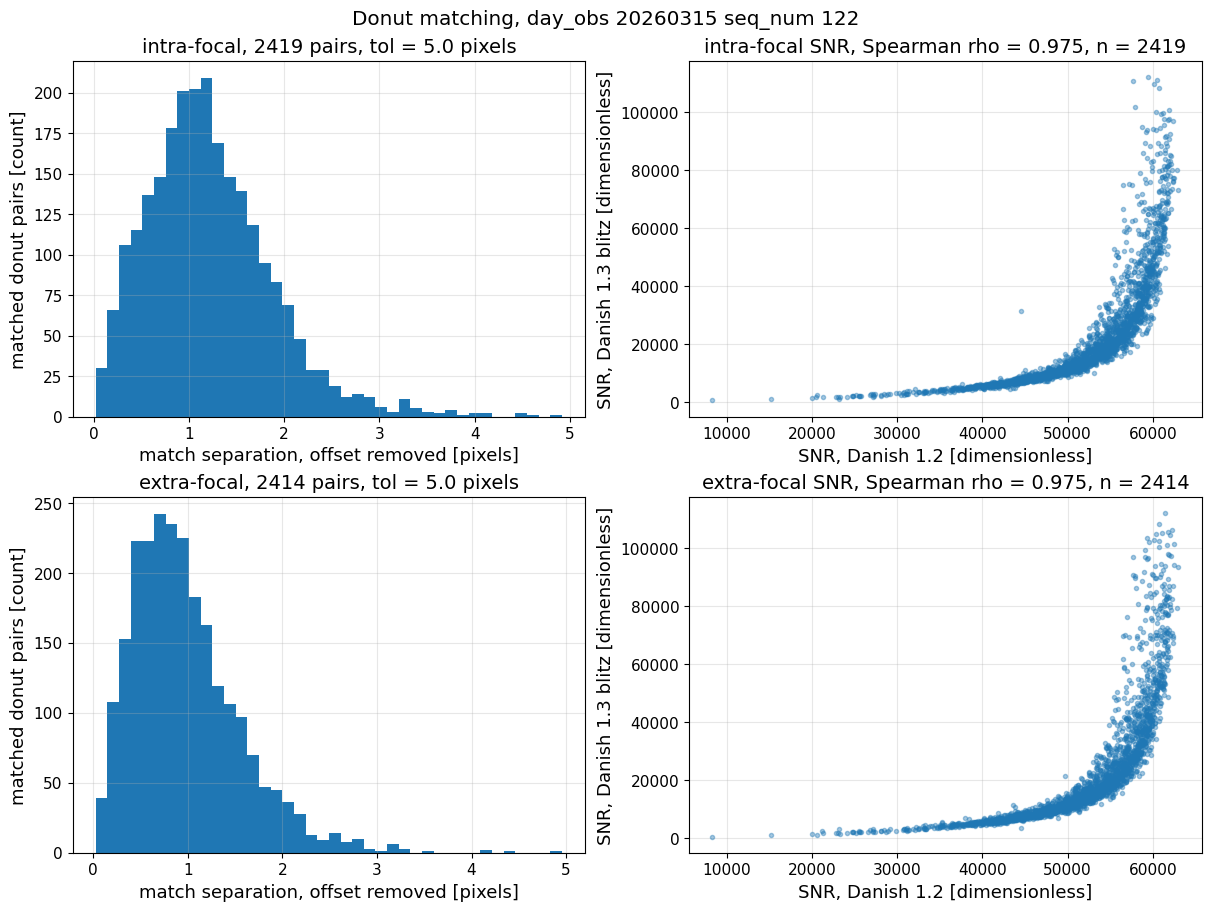

In [15]:
# Signal-to-noise ratio is an independent check that the matched rows are the same
# physical donuts, since the two pipelines measure it separately. The two SNR
# columns are NOT on the same scale -- see the medians below -- so the rank
# correlation is the meaningful statistic and the Pearson r is reported alongside.
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for row, s in enumerate(('intra', 'extra')):
    m = match[s]
    snr_o = np.asarray(old_ok['snr'], dtype=float)[m['idx_old']]
    snr_b = np.asarray(blitz_ok['snr'], dtype=float)[m['idx_blitz']]
    r, rho, n = corr_pair(snr_o, snr_b)
    m['snr_rho'] = rho
    print(f'{s}-focal matched-donut SNR (dimensionless, flux over noise): '
          f'Pearson r = {r:.4f}, Spearman rho = {rho:.4f}, n = {n}')
    print(f'    median SNR, Danish 1.2 = {np.nanmedian(snr_o):9.1f} (dimensionless)')
    print(f'    median SNR, blitz 1.3  = {np.nanmedian(snr_b):9.1f} (dimensionless)')

    axes[row, 0].hist(m['sep_pix'], bins=40)
    axes[row, 0].set_xlabel('match separation, offset removed [pixels]')
    axes[row, 0].set_ylabel('matched donut pairs [count]')
    axes[row, 0].set_title(f'{s}-focal, {len(m["idx_old"])} pairs, '
                           f'tol = {TOL_PIX} pixels')
    axes[row, 1].plot(snr_o, snr_b, 'o', ms=3, alpha=0.4)
    axes[row, 1].set_xlabel('SNR, Danish 1.2 [dimensionless]')
    axes[row, 1].set_ylabel('SNR, Danish 1.3 blitz [dimensionless]')
    axes[row, 1].set_title(f'{s}-focal SNR, Spearman rho = {rho:.3f}, n = {n}')
fig.suptitle(f'Donut matching, day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

<a id='zernike'></a>
## 8. Zernike Comparison

Both products give micrometres of wavefront in the Optical Coordinate System (OCS), so no
scaling or rotation is applied. The intrinsic wavefront is a batoid model evaluation at the
donut's field position, so it is the tighter test of the field-position and frame
conventions; the deviation is the fitted quantity and carries the estimator's noise.

The blitz is unpaired, so each side of focus is reported separately: pooling them would mix
two measurements of the same star against one Danish 1.2 value.

In [16]:
# Gather the matched Zernikes per side of focus.
zk = {}
for s in ('intra', 'extra'):
    m = match[s]
    zk[s] = dict(
        dev_old=np.asarray(old_ok[f'zk_deviation_{COORD_OLD}'],
                           dtype=float)[m['idx_old']],
        int_old=np.asarray(old_ok[f'zk_intrinsic_{COORD_OLD}'],
                           dtype=float)[m['idx_old']],
        dev_blitz=np.asarray(blitz_ok[f'zk_deviation_{COORD_BLITZ}'],
                             dtype=float)[m['idx_blitz']][:, NOLL],
        int_blitz=np.asarray(blitz_ok[f'zk_intrinsic_{COORD_BLITZ}'],
                             dtype=float)[m['idx_blitz']][:, NOLL])
    print(f'{s}-focal matched Zernike arrays: {zk[s]["dev_old"].shape} '
          f'(Danish 1.2) and {zk[s]["dev_blitz"].shape} (blitz), '
          f'{len(NOLL)} Noll indices')

rows = []
for s in ('intra', 'extra'):
    for c, j in enumerate(NOLL):
        d_dev = zk[s]['dev_blitz'][:, c] - zk[s]['dev_old'][:, c]
        d_int = zk[s]['int_blitz'][:, c] - zk[s]['int_old'][:, c]
        r_dev, rho_dev, n_dev = corr_pair(zk[s]['dev_old'][:, c],
                                          zk[s]['dev_blitz'][:, c])
        rows.append(dict(
            side=s, noll=j, name=NOLL_NAMES.get(j, ''),
            dev_mean_old=np.nanmean(zk[s]['dev_old'][:, c]),
            dev_mean_blitz=np.nanmean(zk[s]['dev_blitz'][:, c]),
            dev_nmad_diff=nmad(d_dev),
            dev_pearson_r=r_dev, dev_spearman_rho=rho_dev,
            int_median_absdiff=np.nanmedian(np.abs(d_int)),
            n=n_dev))
zk_compare = pd.DataFrame(rows)
print('\nDeviation and intrinsic Zernike comparison. Means, nMAD and median |difference| '
      'are in um of wavefront (OCS); r and rho are dimensionless.')
with pd.option_context('display.max_rows', 60, 'display.width', 220,
                       'display.float_format', lambda v: f'{v:9.4f}'):
    display(zk_compare)

intra-focal matched Zernike arrays: (2419, 21) (Danish 1.2) and (2419, 21) (blitz), 21 Noll indices
extra-focal matched Zernike arrays: (2414, 21) (Danish 1.2) and (2414, 21) (blitz), 21 Noll indices

Deviation and intrinsic Zernike comparison. Means, nMAD and median |difference| are in um of wavefront (OCS); r and rho are dimensionless.


,side,noll,name,dev_mean_old,dev_mean_blitz,dev_nmad_diff,dev_pearson_r,dev_spearman_rho,int_median_absdiff,n
0,intra,4,Defocus,-0.4560,-0.5086,0.0522,0.8630,0.8793,0.0014,2419
1,intra,5,Astig45,0.0863,0.0798,0.1424,0.8322,0.8557,0.0003,2419
2,intra,6,Astig0,-0.1911,-0.3295,0.1427,0.5557,0.5974,0.0004,2419
3,intra,7,Coma_y,0.1079,0.2887,0.0810,0.6621,0.7124,0.0001,2419
4,intra,8,Coma_x,0.2389,0.2566,0.0700,0.7210,0.8259,0.0001,2419
5,intra,9,Trefoil_y,0.0311,-0.0171,0.0553,0.8194,0.8263,0.0001,2419
6,intra,10,Trefoil_x,-0.0976,-0.0582,0.0607,0.7982,0.7793,0.0001,2419
7,intra,11,Spherical,0.1905,0.3215,0.0138,0.8337,0.9114,0.0001,2419
8,intra,12,2ndAstig0,-0.1536,-0.1269,0.0371,0.8796,0.8705,0.0000,2419
9,intra,13,2ndAstig45,-0.0256,-0.0342,0.0480,0.8288,0.8358,0.0000,2419


In [17]:
print('Intrinsic wavefront agreement (batoid model at the matched field position).')
print('This is the tight test: it depends only on the field position and the frame, '
      'not on the fit.')
for s in ('intra', 'extra'):
    d_int = zk[s]['int_blitz'] - zk[s]['int_old']
    print(f'  {s:5s}: median |Danish 1.3 - Danish 1.2| over '
          f'{len(zk[s]["int_old"])} donuts and {len(NOLL)} Noll = '
          f'{np.nanmedian(np.abs(d_int)):.3e} um of wavefront')
    print(f'         median |Danish 1.2 intrinsic| for scale = '
          f'{np.nanmedian(np.abs(zk[s]["int_old"])):.4f} um of wavefront')

print('\nDeviation (fitted) agreement, per side of focus:')
for s in ('intra', 'extra'):
    sub = zk_compare[zk_compare.side == s]
    worst = sub.loc[sub.dev_nmad_diff.idxmax()]
    print(f'  {s:5s}: nMAD of the difference spans '
          f'{sub.dev_nmad_diff.min():.4f} to {sub.dev_nmad_diff.max():.4f} '
          f'um of wavefront, largest on Z{int(worst.noll)} {worst["name"]}')
    z4 = sub[sub.noll == 4].iloc[0]
    print(f'         Z4 Defocus deviation: Pearson r = {z4.dev_pearson_r:.4f}, '
          f'Spearman rho = {z4.dev_spearman_rho:.4f}, n = {int(z4.n)}')
    print(f'         median Pearson r over the {len(sub)} Noll = '
          f'{sub.dev_pearson_r.median():.4f} (dimensionless)')

Intrinsic wavefront agreement (batoid model at the matched field position).
This is the tight test: it depends only on the field position and the frame, not on the fit.
  intra: median |Danish 1.3 - Danish 1.2| over 2419 donuts and 21 Noll = 3.875e-05 um of wavefront
         median |Danish 1.2 intrinsic| for scale = 0.0069 um of wavefront
  extra: median |Danish 1.3 - Danish 1.2| over 2414 donuts and 21 Noll = 3.806e-05 um of wavefront
         median |Danish 1.2 intrinsic| for scale = 0.0069 um of wavefront

Deviation (fitted) agreement, per side of focus:
  intra: nMAD of the difference spans 0.0031 to 0.1427 um of wavefront, largest on Z6 Astig0
         Z4 Defocus deviation: Pearson r = 0.8630, Spearman rho = 0.8793, n = 2419
         median Pearson r over the 21 Noll = 0.7367 (dimensionless)
  extra: nMAD of the difference spans 0.0033 to 0.1249 um of wavefront, largest on Z5 Astig45
         Z4 Defocus deviation: Pearson r = 0.8751, Spearman rho = 0.8787, n = 2414
         media

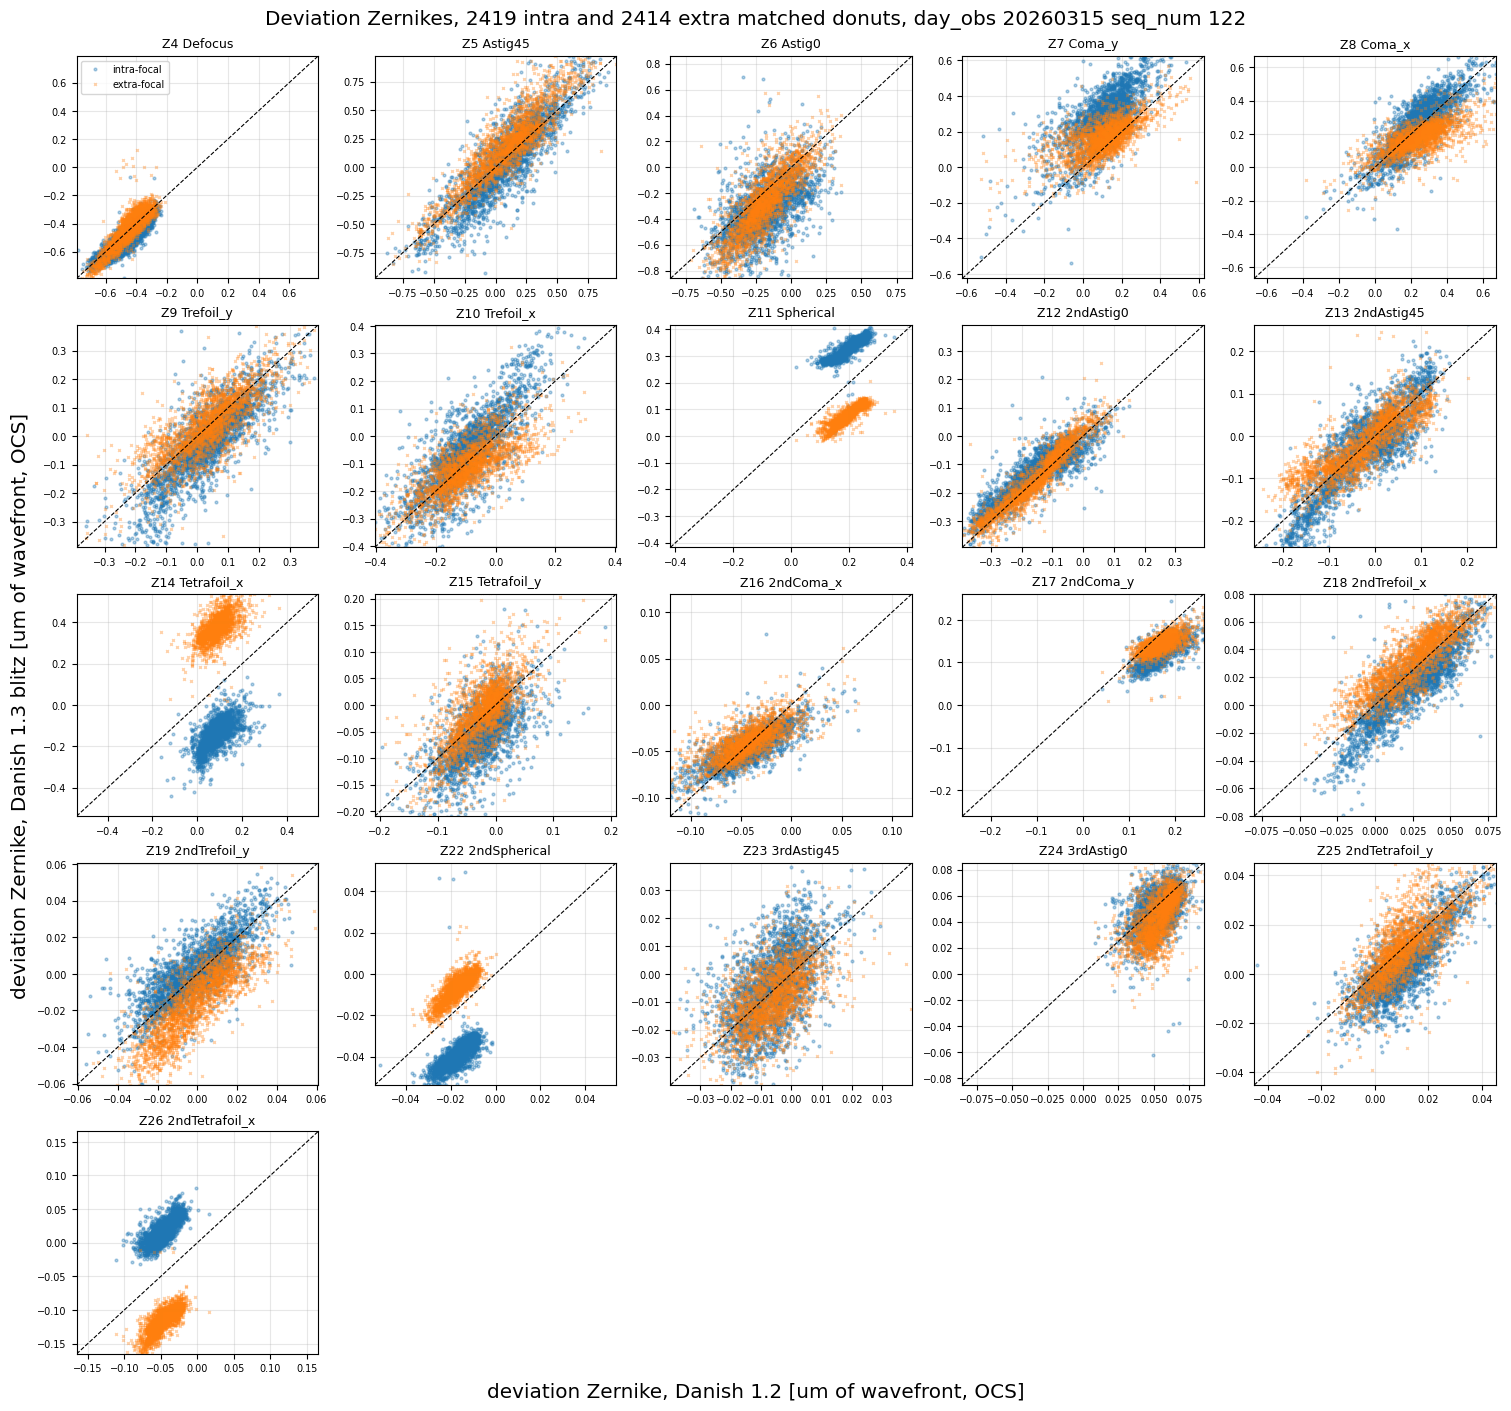

In [18]:
# Per-Noll scatter, blitz against Danish 1.2, both sides of focus overlaid.
ncol = 5
nrow = int(np.ceil(len(NOLL) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.8 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    vals = []
    for s, mk in (('intra', 'o'), ('extra', 'x')):
        ax.plot(zk[s]['dev_old'][:, c], zk[s]['dev_blitz'][:, c], mk, ms=2,
                alpha=0.35, label=f'{s}-focal')
        vals += [zk[s]['dev_old'][:, c], zk[s]['dev_blitz'][:, c]]
    both = np.concatenate(vals)
    both = both[np.isfinite(both)]
    if len(both):
        lim = np.nanpercentile(np.abs(both), 99) * 1.1
        ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)
    ax.set_title(zk_label(j), fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(NOLL):]:
    ax.set_visible(False)
axes.flat[0].legend(fontsize=7)
fig.supxlabel('deviation Zernike, Danish 1.2 [um of wavefront, OCS]')
fig.supylabel('deviation Zernike, Danish 1.3 blitz [um of wavefront, OCS]')
fig.suptitle(f'Deviation Zernikes, '
             f'{len(match["intra"]["idx_old"])} intra and '
             f'{len(match["extra"]["idx_old"])} extra matched donuts, '
             f'day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

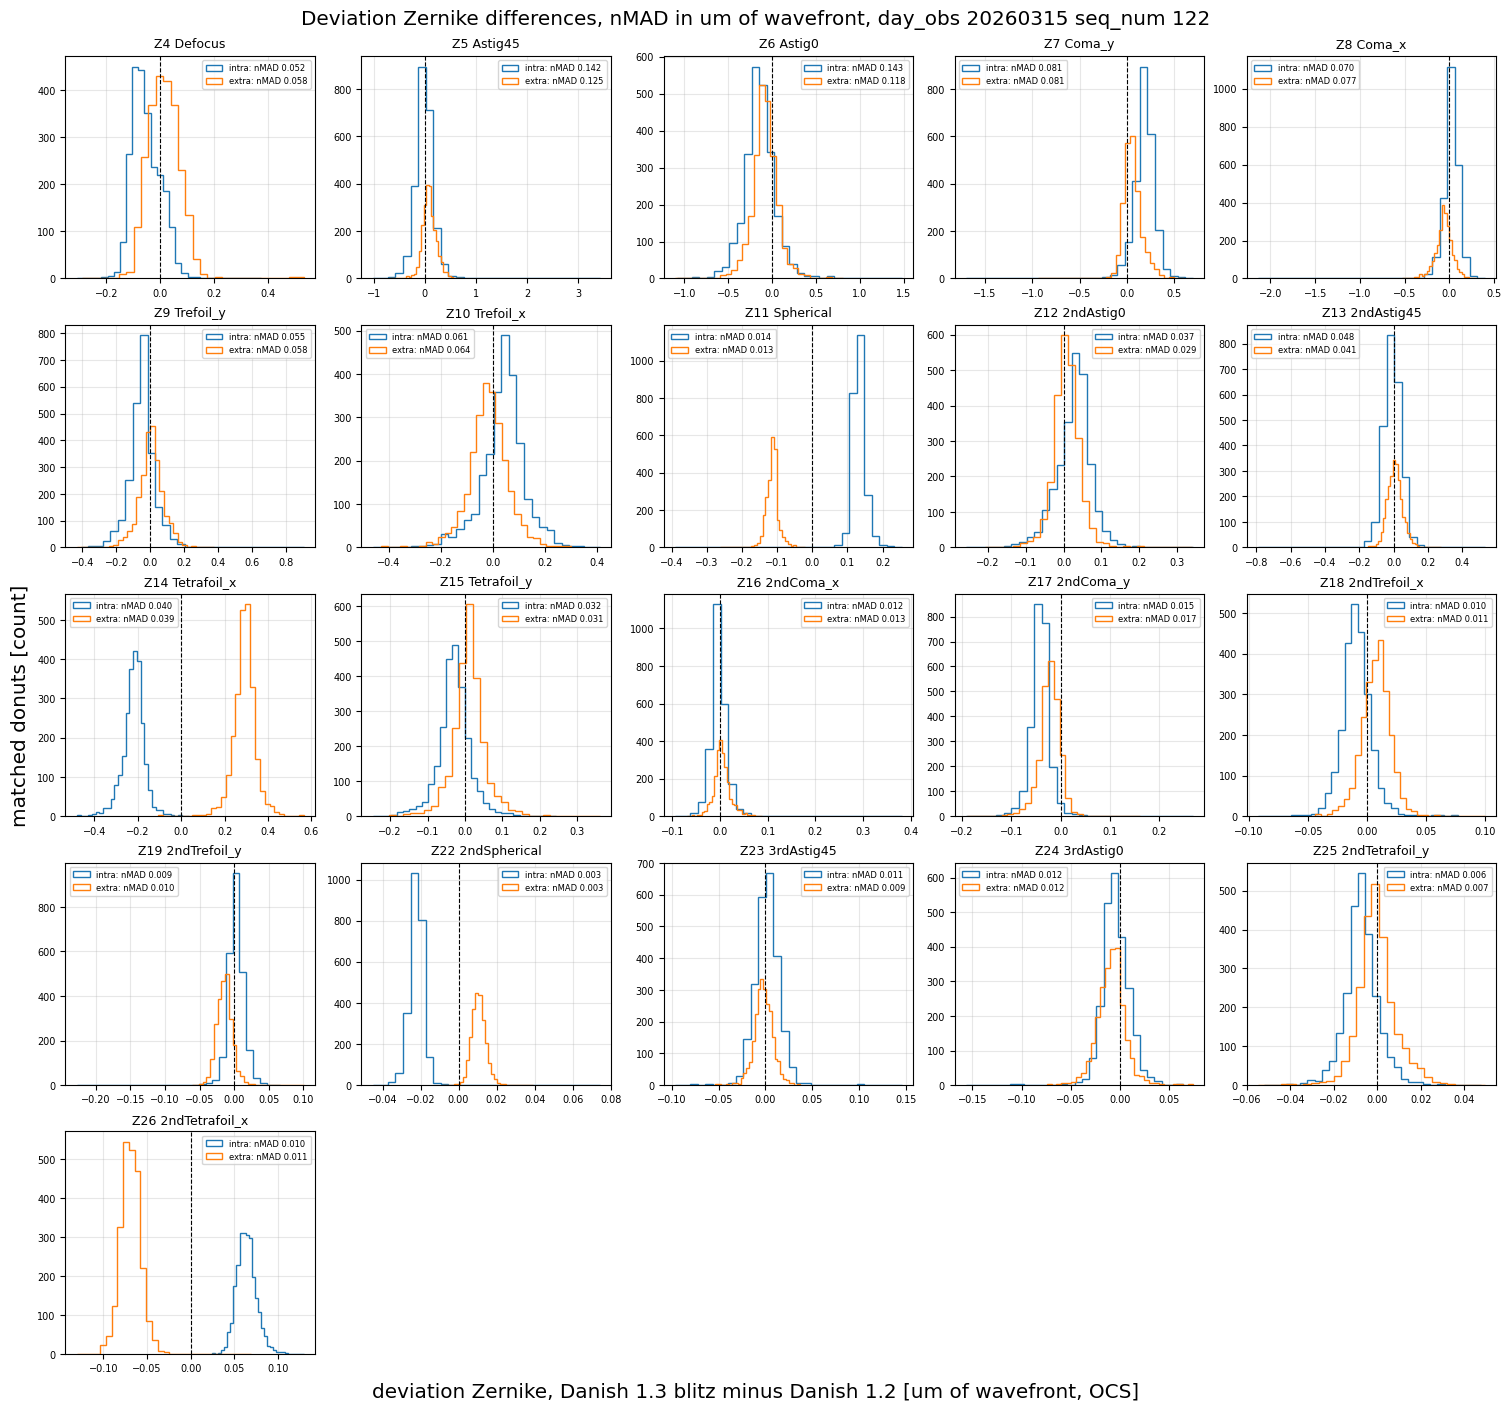

In [19]:
# Per-Noll difference distributions, with the robust scatter annotated.
fig, axes = plt.subplots(nrow, ncol, figsize=(3.0 * ncol, 2.8 * nrow))
for c, j in enumerate(NOLL):
    ax = axes.flat[c]
    for s in ('intra', 'extra'):
        d = zk[s]['dev_blitz'][:, c] - zk[s]['dev_old'][:, c]
        d = d[np.isfinite(d)]
        if len(d):
            ax.hist(d, bins=30, histtype='step',
                    label=f'{s}: nMAD {nmad(d):.3f}')
    ax.axvline(0.0, color='k', ls='--', lw=0.8)
    ax.set_title(zk_label(j), fontsize=9)
    ax.legend(fontsize=6)
    ax.tick_params(labelsize=7)
for ax in axes.flat[len(NOLL):]:
    ax.set_visible(False)
fig.supxlabel('deviation Zernike, Danish 1.3 blitz minus Danish 1.2 '
              '[um of wavefront, OCS]')
fig.supylabel('matched donuts [count]')
fig.suptitle(f'Deviation Zernike differences, nMAD in um of wavefront, '
             f'day_obs {DAY_OBS} seq_num {SEQ_EXTRA}')
plt.show()

<a id='corner'></a>
## 9. Corner / In-Focus Product

`donutBlitzResults` on the in-focus (`acq`) member of the triplet covers the corner
wavefront sensors (CWFS). It carries exactly the FAM columns plus three image columns, so
it is the product to read when the donut cutout and the model fit are wanted. No Danish 1.2
counterpart is loaded for the in-focus exposure in this first pass.

In [20]:
cols_fam = set(blitz_fam.colnames)
cols_corner = set(blitz_corner.colnames)
print(f'corner-only columns: {sorted(cols_corner - cols_fam)}')
print(f'FAM-only columns   : {sorted(cols_fam - cols_corner)}')
for c in sorted(cols_corner - cols_fam):
    a = np.asarray(blitz_corner[c])
    print(f'  {c:12s} shape per row = {a.shape[1:]}, dtype = {a.dtype}')

det_corner = np.asarray(blitz_corner['det_name'], dtype=str)
print(f'\ncorner detectors ({len(set(det_corner))}): {sorted(set(det_corner))}')
cand_c = np.asarray(blitz_corner['candidate'], dtype=bool)
fit_c = np.asarray(blitz_corner['group_fit_success'], dtype=bool)
print(f'corner rows: {len(blitz_corner)} total, {int(cand_c.sum())} candidate, '
      f'{int(fit_c.sum())} with group_fit_success')

# The same focus_side helper as the FAM product. This is why it finds the varying
# element instead of assuming one: the two blitz products put the defocal offset in
# DIFFERENT elements of the 3-vector, so a hardcoded index mislabels one of them.
side_c, off_element_c = focus_side(blitz_corner)
off_c = np.asarray(blitz_corner['defocal_offsets'], dtype=float)
print(f'\ncorner defocal_offsets varies in element {off_element_c}, '
      f'while the FAM product varies element {off_element}:')
for row in np.unique(off_c, axis=0):
    print(f'    {row} [m]   count = {int((off_c == row).all(axis=1).sum())} rows')
print(f'corner focus sides: intra {int((side_c == "intra").sum())} rows, '
      f'extra {int((side_c == "extra").sum())} rows')

corner-only columns: ['model_img', 'stamp', 'wf_img']
FAM-only columns   : []
  model_img    shape per row = (83, 83), dtype = float64
  stamp        shape per row = (167, 167), dtype = float64
  wf_img       shape per row = (83, 83), dtype = float64

corner detectors (8): [np.str_('R00_SW0'), np.str_('R00_SW1'), np.str_('R04_SW0'), np.str_('R04_SW1'), np.str_('R40_SW0'), np.str_('R40_SW1'), np.str_('R44_SW0'), np.str_('R44_SW1')]
corner rows: 68 total, 58 candidate, 58 with group_fit_success

corner defocal_offsets varies in element 0, while the FAM product varies element 1:
    [-0.0015  0.      0.    ] [m]   count = 28 rows
    [0.0015 0.     0.    ] [m]   count = 40 rows
corner focus sides: intra 28 rows, extra 40 rows


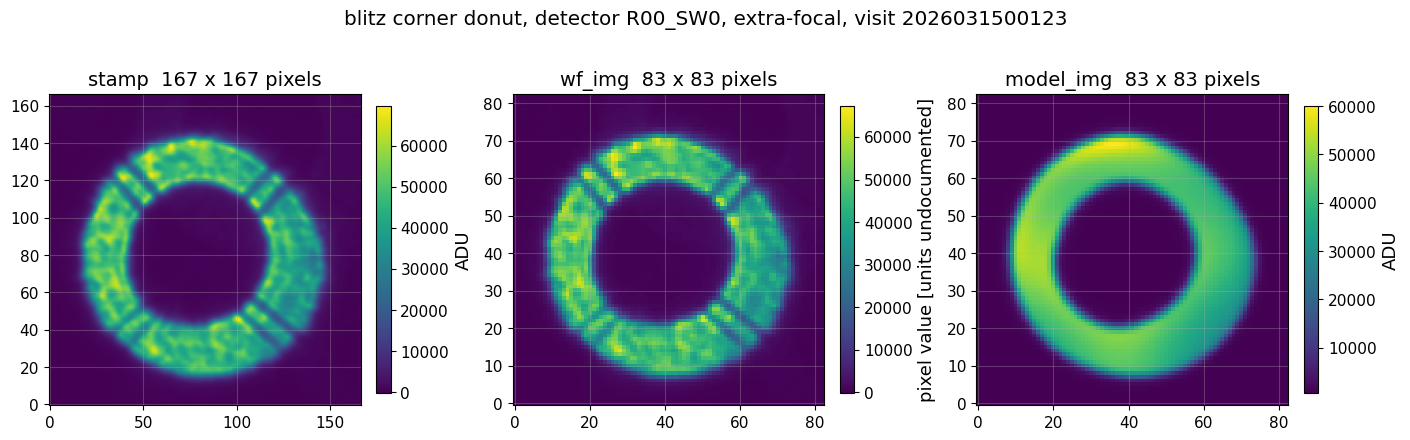

stamp     :  27889 finite of  27889 pixels, range    -146.4376 to   69601.2578, median    1355.2618
wf_img    :   6889 finite of   6889 pixels, range     -78.9125 to   67245.2969, median    1406.0376
model_img :   6889 finite of   6889 pixels, range     625.1847 to   60005.2447, median     954.1672

The wf_img range is of order 1e4, so it is not micrometres of wavefront; the units are not documented in the table.


In [21]:
# One fitted corner donut: the stamp, the wf_img and the model image. The stamp and
# model_img are in ADU. The units of wf_img are NOT stated by the table and its range
# below is far too large for micrometres of wavefront, so it is left unlabelled here
# and listed in section 10 as a question for Josh.
i_show = int(np.where(fit_c)[0][0])
fig, axes = plt.subplots(1, 3, figsize=(14, 4.6), layout='constrained')
for ax, col, unit in ((axes[0], 'stamp', 'ADU'),
                      (axes[1], 'wf_img', 'pixel value [units undocumented]'),
                      (axes[2], 'model_img', 'ADU')):
    img = np.asarray(blitz_corner[col][i_show], dtype=float)
    im = ax.imshow(img, origin='lower')
    ax.set_title(f'{col}  {img.shape[0]} x {img.shape[1]} pixels')
    fig.colorbar(im, ax=ax, label=unit, fraction=0.046)
fig.suptitle(f'blitz corner donut, detector {det_corner[i_show]}, '
             f'{side_c[i_show]}-focal, visit {VISIT_ACQ}')
plt.show()

for col in ('stamp', 'wf_img', 'model_img'):
    img = np.asarray(blitz_corner[col][i_show], dtype=float)
    print(f'{col:10s}: {int(np.isfinite(img).sum()):6d} finite of {img.size:6d} pixels, '
          f'range {np.nanmin(img):12.4f} to {np.nanmax(img):12.4f}, '
          f'median {np.nanmedian(img):12.4f}')
print('\nThe wf_img range is of order 1e4, so it is not micrometres of wavefront; '
      'the units are not documented in the table.')

<a id='findings'></a>
## 10. Findings for Josh

Every number below is from the executed cells above, for `day_obs = 20260315`,
`seq_num = 122` (extra-focal FAM key) and `seq_num = 123` (in-focus).

### Do the values agree with Danish 1.2?

Yes for the intrinsic, only roughly for the fitted deviation.

- **Intrinsic wavefront: exact agreement.** Over 2419 intra-focal and 2414 extra-focal
  matched donuts and the 21 fitted Noll, the median
  |Danish 1.3 − Danish 1.2| is **3.9e-05 µm of wavefront** (intra) and
  **3.8e-05 µm of wavefront** (extra), against a median |intrinsic| of
  **0.0069 µm of wavefront**. So the field-position convention, the frame and the units
  all match with no scaling — a ratio of 5.6e-03 (dimensionless, difference over signal).
- **Fitted deviation: correlated but not close.** Per Noll, the nMAD of the difference
  spans **0.0031 to 0.1427 µm of wavefront** (intra, largest on Z6 Astig0) and
  **0.0033 to 0.1249 µm of wavefront** (extra, largest on Z5 Astig45). The median
  Pearson r over the 21 Noll is **0.737** (intra) and **0.743** (extra), dimensionless,
  n = 2419 and 2414. Even Z4 Defocus, the best-determined term, gives only
  Pearson r = 0.863 / Spearman rho = 0.879 (intra) and 0.875 / 0.879 (extra).
  Some of this is genuine: the blitz is **unpaired**, so each blitz row is one exposure's
  estimate while the Danish 1.2 value is a joint intra+extra fit, and the unpaired
  estimate is intrinsically noisier. The per-Noll mean offsets are the part worth
  checking — for example Z7 Coma_y means 0.108 (Danish 1.2) against 0.289 (blitz, intra)
  and Z14 Tetrafoil_x 0.086 against 0.376 (blitz, extra), both in µm of wavefront, which
  is larger than the nMAD of the difference and so looks like a systematic rather than
  noise.

### Format observations

**Metadata is the largest gap.** Both blitz products have an **empty `meta`**. The
Danish 1.2 `aggregateAOSVisitTableRaw` carries 12 keys: `visit`, `parallacticAngle`,
`rotAngle`, `rotTelPos`, `ra`, `dec`, `az`, `alt`, `band`, `mjd`, `nollIndices` and a
per-donut `estimatorInfo`. Of these, `nollIndices` and the rotator angles are the ones
consumed downstream: the fitted Noll set currently has to be inferred from which columns
are zero or NaN, and the camera rotator angle has to be fetched from the Consolidated
Database (ConsDB) instead of travelling with the table.

**Only 3 of 58 blitz column names are shared with the Danish 1.2 table** — `coord_ra`,
`coord_dec` and `snr` — and `snr` is not the same quantity despite the name (below). So
this is a new schema rather than an extension, and every downstream reader has to be
rewritten rather than adapted.

**The deviation vector's unused entries are encoded two different ways.** In the 27-long
`zk_deviation_ocs`, Noll 0 through 3 are **identically zero** while Noll 20 and 21 are
**all-NaN**, although both groups are equally "not fitted". The NaN pair is exactly what
the Danish 1.2 `nollIndices = [4..19, 22..26]` omits, so the convention is recoverable,
but one encoding for both — or an explicit index list in the metadata — would remove the
guesswork.

**`snr` is not the same quantity in the two products.** On matched donuts the medians are
**52850 (Danish 1.2)** against **15838 (blitz)**, dimensionless, so the columns differ by
roughly a factor 3.3 and are not interchangeable. The rank correlation is excellent
(Spearman rho = 0.975, n = 2419), which is what confirms the match, but the Pearson r is
only 0.737 because the relation is not linear. A note on the definition, or a distinct
column name, would prevent a silent misuse.

**Centroid positions carry a constant few-pixel offset relative to Danish 1.2.** Matching
per CCD needs a shift of **(dx, dy) = (−3.35, −3.98) pixels** on the intra-focal side and
**(−3.06, −3.80) pixels** on the extra-focal side (blitz `x_det`/`y_det` minus the
Danish 1.2 `centroid_*`). With the shift removed the median separation is
**1.138 pixels** (intra) and **0.885 pixels** (extra); without it the match is dominated
by accidental neighbours. This looks like a pixel-origin or a binning convention
difference (the Danish 1.2 collection is `bin_x2`) and is worth pinning down explicitly.

**`defocal_offsets` uses a different element in the two products.** `donutBlitzFamResults`
varies **element 1** (`[0, ±0.0015, 0]` m) while `donutBlitzResults` varies **element 0**
(`[±0.0015, 0, 0]` m). A reader that hardcodes an index will silently mislabel the side of
focus in one of the two. Which physical axis each element is, is not stated anywhere in
the table.

**Unpaired output needs an explicit focus-side column.** The side of focus is recoverable
only from the sign of whichever `defocal_offsets` element happens to vary, which is the
same problem from the other direction.

**`wf_img` units are undocumented and are not micrometres of wavefront.** On the corner
product, `wf_img` is 83×83 pixels with a range of **−78.9 to 67245** and a median of
**1406** — the same order as `stamp` (−146 to 69601 ADU) and `model_img`
(625 to 60005 ADU). So it appears to be an image in ADU rather than a wavefront map, and
the name is misleading.

**Missing relative to Danish 1.2**, for work that currently depends on them:
- No North/West sky-frame Zernikes (`zk_NW`) or sky-frame field angles (`th_N`, `th_W`).
  The blitz gives CCS, OCS and the new `eb` frame.
- No total `zk`, only the `zk_deviation` and `zk_intrinsic` split. Danish 1.2 carries all
  three, and `zk − zk_intrinsic − zk_deviation` is a useful self-check.
- No per-donut fit-quality scalar comparable to `blur` or `chi2`. The blitz
  `group_fit_cost` and `group_fit_optimality` are per group, not per donut.

**The `eb` frame is undocumented.** `zk_deviation_eb` and `zk_intrinsic_eb` sit alongside
the CCS and OCS pair with no definition.

### Things the notebook resolved, so they are not questions

- **`group_fit_success` is a clean selection flag.** It is True on 6931 of 7652 rows and is
  exactly the set with a finite deviation vector on all 21 fitted Noll — zero rows
  disagree in either direction. `candidate` is True on 6933 and `group_size` is
  `{0: 719, 1: 6933}`, so `group_fit_outcome = 'exception'` accounts for the 2-row gap.
- **`rejected_*` flags ARE populated on this visit**: `rejected_sat` 684,
  `rejected_outer_frac` 148, `rejected_inner_frac` 75, `rejected_snr` 41 rows. An earlier
  look at a different visit (`seq_num = 73`) found none set, so that was visit-dependent
  rather than a blanket bug.
- **`donut_id` cannot be used to match.** Danish 1.2 uses a positional string
  (`2026031500122_001_000`), the blitz a Gaia source id; the intersection is 0 of 3414 and
  3920 unique values.
- **Detector coverage is almost identical**: 181 detectors in the blitz against 180 in
  Danish 1.2, the extra one being `R30_S12`.

### Remaining question

- Is `zk_intrinsic` (length 67, finite through index 66) Noll 4 through 66 on the same
  0-indexed convention as the 27-long deviation vector? The value comparison above assumes
  so and the 3.9e-05 µm of wavefront agreement supports it, but it is worth confirming
  rather than inferring.